<a href="https://colab.research.google.com/github/ImagingDataCommons/idc-comppath-reproducibility/blob/main/lung_cancer_experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook is part of the publication [**The NCI Imaging Data Commons as a platform for reproducible research in computational pathology**](https://doi.org/10.1016/j.cmpb.2023.107839), which describes two experiments that outline how the Imaging Data Commons (IDC) can be used for reproducible computational pathology research. The two experiments are based on a common use case: the AI-based classification of lung tissue regions into either non-neoplastic (normal), adenocarcinoma (LUAD), or squamous cell carcinoma (LSCC) tissue.
The [first experiment](https://github.com/ImagingDataCommons/idc-comppath-reproducibility/blob/main/lung_cancer_experiment_1.ipynb) uses the IDC for a complete development process, including model training and validation on TCGA data. This notebook implements the **second experiment**, in which a pre-trained model from the first experiment is applied to independent data from the CPTAC project. It is self-contained, so it is not required to have a look at the first experiment beforehand.  

This notebook is intended to be run with Google Colaboratory. The total runtime is usually less than two hours. There is also a special demo mode where a complete run only takes a few minutes (see below).

In summary, this notebook shows:

- how to select and access slide microscopy data from the IDC;
- how to process slide microscopy images in DICOM format;
- how to perform **classification using a pre-trained neural network model** and visualize the results exploiting the IDC platform.

# Manual settings

Before the notebook can run automatically some settings have to be configured manually. It is also suggested to copy this notebook in your private Google Drive (by clicking on the respective button in the headline of this notebook), which ensures that changes are saved even when runtimes disconnect.

**Step 1: Enable GPU:** This notebook is intended to be run with a GPU. In Google Colaboratory, GPU usage can be enabled via Edit > Notebooks Settings > Hardware accelerator. Since Colaboratory notebooks are assigned arbitrary GPUs, processing times can vary.  During the first steps of the notebook (which do not utilize the GPU) Colaboratory might ask if you want to switch back to a CPU. If so, **please deny** that by closing the notification. The code below checks whether GPU usage has been enabled and which GPU type the Colaboratory instance is equipped with.

In [1]:
gpu_list = !nvidia-smi --list-gpus
has_gpu = False if 'failed' in gpu_list[0] else True
print(has_gpu, gpu_list)

True ['GPU 0: Tesla T4 (UUID: GPU-1a0ae785-aaad-4045-05a7-58b027047c33)']


**Step 2: Ensure package dependencies:** Run this cell to make sure that the library dependencies are installed in the correct versions. At the end, you are prompted to restart the runtime by clicking on a corresponding button. Please do so, then continue with the next cell.

In [ ]:
!pip3 install matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2\
    Pillow==11.3.0 pydicom==3.0.1 scikit_learn==1.6.1\
    scipy==1.16.1 seaborn==0.13.2 tensorflow==2.19.0\
    tqdm==4.67.1 wsidicom==0.27.1

**Step 3: Authenticate:** To access IDC resources, you have to authenticate with your Google identity. Follow the instructions produced by the code below to complete the Google authentication process.

In [3]:
from google.colab import auth
auth.authenticate_user()

**Step 4: Specify your Google Cloud Platform project ID**:
In order to access image data from the IDC storage in Google Colaboratory you need to have a Google Cloud Platform (GCP) project. This is necessary even though this notebook will run completely **free of cost**. If you don't have one already, you can create your own project by performing the four steps described [here](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/getting_started/part1_prerequisites.ipynb) in section "Activate GCP for your account and create a GCP project". Once you have the google project, set `GC_PROJECT_ID` below to the ID of your GCP project.

In [4]:
GC_PROJECT_ID = 'idc-pathomics-000'

**Step 5: Demo mode:** To quickly get an impression of how this notebook works, it can be run in demo mode. Then only a fraction of slides are considered and processing is done at reduced magnification. In demo mode, a complete run of the notebook only takes a few minutes, but at the cost of greatly reduced classification accuracy.

In [5]:
DEMO_MODE = False

**Step 6: Run** the notebook by clicking on **Runtime > Restart and run all**

# Utility code

Utility functionality for accessing whole-slide images (WSIs) in the IDC and for evaluating results is summarized in the idc_comppath_reproducibility package. The code is available open source and can be re-used for similar use cases. In the cell below, the idc_comppath_reproducibility package is cloned to the current Colaboratory instance.

In [ ]:
!git clone -b main https://github.com/ImagingDataCommons/idc-comppath-reproducibility.git

# Imports

In [ ]:
import os
import time
from datetime import timedelta
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from PIL import Image
from tqdm.auto import tqdm
from tensorflow.keras.models import load_model

import sys
sys.path.append('./idc-comppath-reproducibility')
from idc_comppath_reproducibility.utils import create_slides_metadata, get_stratified_subsample
from idc_comppath_reproducibility.wsi import WSI
from idc_comppath_reproducibility.batch_iterator import BatchIterator
from idc_comppath_reproducibility.predictions import Predictions
from idc_comppath_reproducibility.roc import perform_tile_based_roc_analysis, perform_slide_based_roc_analysis, summarize_roc_values
from idc_comppath_reproducibility.heatmap import select_slides_for_heatmap, plot_colormap_legend, generate_heatmap
from idc_comppath_reproducibility.global_variables import CLASS_LABEL_TO_INDEX_MAP, NUM_CLASSES

# Global constants

In [8]:
if DEMO_MODE:
    NUM_SLIDES = 45
    PIXEL_SPACING = 0.002 # in mm/px
    TILE_SIZE = 128 # in px
    MODEL_URL = 'https://api.github.com/repos/ImagingDataCommons/idc-comppath-reproducibility/releases/assets/98547212'
    MODEL_FILE_PATH = './tcga_pretrained_model128.zip'
else:
    NUM_SLIDES = 300
    PIXEL_SPACING = 0.001 # in mm/px
    TILE_SIZE = 256 # in px
    MODEL_URL = 'https://api.github.com/repos/ImagingDataCommons/idc-comppath-reproducibility/releases/assets/98547238'
    MODEL_FILE_PATH = './tcga_pretrained_model256.zip'

# Enable determinism

To enable reproducibility we aim to make all operations in this notebook deterministic. An important part to this is setting random seeds and enabling TensorFlow operations to be deterministic.

In [9]:
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)
tf.config.experimental.enable_op_determinism()

# Data selection

For most computational pathology experiments, the first step is to select a cohort of WSIs by filtering for the desired metadata attributes.

The IDC uses the DICOM standard for data representation. Here, a WSI corresponds to a series of DICOM image objects, each representing the slide at a different resolution. Each DICOM object is stored as a separate DICOM file. Cohort selection is done best by executing BigQuery SQL statements against the **bigquery-public-data.idc_v11.dicom_all** table, which lists all available DICOM files (rows) with the corresponding metadata atrributes (columns).

The following BigQuery SQL statement retrieves all DICOM files (including their metadata) in the CPTAC-LUAD and CPTAC-LSCC collections that are of interest for our use case.

In [10]:
start_time = time.time() # measure time of notebook execution

In [22]:
%%bigquery bq_results_df --project=$GC_PROJECT_ID

-- First, create subqueries to facilitate data selection from the dicom_all table.
-- Several DICOM attributes are renamed to be more intuitive (e.g. 'TotalPixelMatrixColumns' is renamed to 'width').
WITH
  -- The 'sm_images' subquery summarizes basic metadata of slide microscopy images (SM).
  sm_images AS (
    SELECT
      -- digital_slide_id: unique numeric identifier of a digital slide, i.e., a digital image of a physical slide.
      SeriesInstanceUID AS digital_slide_id,
      -- case_id: unique numeric identifier of the study in the context of which the ditial slide was created.
      StudyInstanceUID AS case_id,
      -- physical_slide_id: unique numeric identifier of the physical slide as prepared in the wet lab.
      ContainerIdentifier AS physical_slide_id,
      -- patient_id: unique numeric identifier of the patient from whose tissue the physical slide was obtained.
      PatientID AS patient_id,
      -- width: image width in pixels.
      TotalPixelMatrixColumns AS width,
      -- height: image height in pixels.
      TotalPixelMatrixRows AS height,
      -- collection_id: numeric or character sequence describing the dataset the physical slide is part of.
      collection_id,
      -- crdc_instance_uuid: universally unique identifier of the DICOM instance.
      crdc_instance_uuid,
      -- gcs_url: GCS URL needed to access the DICOM file
      gcs_url AS gcs_url_v11,
      -- pixel_spacing: image pixel spacing in mm/px
      CAST(SharedFunctionalGroupsSequence[SAFE_OFFSET(0)].
              PixelMeasuresSequence[SAFE_OFFSET(0)].
              PixelSpacing[SAFE_OFFSET(0)] AS FLOAT64) AS pixel_spacing,
      -- compression: compression type
      CASE TransferSyntaxUID
          WHEN '1.2.840.10008.1.2.4.50' THEN 'jpeg'
          WHEN '1.2.840.10008.1.2.4.91' THEN 'jpeg2000'
          ELSE 'other'
      END AS compression,
    FROM
      -- we are using version 11 of the IDC data
      bigquery-public-data.idc_v11.dicom_all
    WHERE
      -- limit query to slide microscopy images (SM) excluding non-volume images like label images
      Modality = 'SM' AND ImageType[OFFSET(2)] = 'VOLUME'
  ),

  -- The 'tissue_types' subquery indicates whether a slides contains normal, tumor or other tisse.
  tissue_types AS (
    SELECT DISTINCT *
    FROM (
      SELECT
        SeriesInstanceUID AS digital_slide_id,
        CASE steps_unnested2.CodeValue
            WHEN '17621005' THEN 'normal' -- meaning: 'Normal' (i.e., non neoplastic)
            WHEN '86049000' THEN 'tumor' -- meaning: 'Neoplasm, Primary'
            ELSE 'other' -- meaning: 'Neoplasm, Metastatic'
        END AS tissue_type
      FROM
        bigquery-public-data.idc_v11.dicom_all
        CROSS JOIN
          UNNEST (SpecimenDescriptionSequence[SAFE_OFFSET(0)].PrimaryAnatomicStructureSequence) AS steps_unnested1
        CROSS JOIN
          UNNEST (steps_unnested1.PrimaryAnatomicStructureModifierSequence) AS steps_unnested2
    )
  ),

  -- Create lookup table for latest gcs_urls
  -- (bucket organization has been changed from v14 and the old organization is deprecated since the end of 2025)
  latest_urls AS (
    SELECT
      crdc_instance_uuid,
      gcs_url AS gcs_url_latest
    FROM
      bigquery-public-data.idc_current.dicom_all
  )


-- Select all DICOM files from the CPTAC-LUAD / CPTAC-LUSC datasets that are JPEG/JPEG2000 compressed and
-- contain normal or tumor tissue. We do not need to restrict the query to frozen tissue sections since all
-- slides in CPTAC show frozen tissue. The results are ordered by their crdc_instance_uuid to ensure
-- deterministic output order which is important for reproducibility.
SELECT
  a.* EXCEPT (gcs_url_v11),
  b.tissue_type,
  (REPLACE (REPLACE(collection_id, 'cptac_luad', 'luad'), 'cptac_lscc', 'lscc')) AS cancer_subtype,
  c.gcs_url_latest as gcs_url
FROM
  sm_images AS a
  JOIN tissue_types AS b ON b.digital_slide_id=a.digital_slide_id
  LEFT JOIN latest_urls AS c USING (crdc_instance_uuid)
WHERE
  (a.collection_id = 'cptac_luad' OR a.collection_id = 'cptac_lscc')
  AND a.compression != 'other'
  AND (b.tissue_type = 'normal' OR b.tissue_type = 'tumor')
ORDER BY a.crdc_instance_uuid

Query is running:   0%|          |

Downloading:   0%|          |

The metadata are reorganized into a dataframe containing one row per WSI. Then, a stratified subsample of the data is selected for the analysis.

In [23]:
slides_metadata = create_slides_metadata(bq_results_df)
slides_metadata = get_stratified_subsample(slides_metadata, NUM_SLIDES, random_state=0)

In [24]:
# Assert uniqueness of physical slide ID values
assert(slides_metadata['digital_slide_id'].is_unique)

# Assert validity of class labels
assert set(slides_metadata['tissue_type'].unique()) == set(['normal', 'tumor'])
assert set(slides_metadata['cancer_subtype'].unique()) == set(['luad', 'lscc'])

display(slides_metadata.head())
print('Total number of slides: ', len(slides_metadata))
nr_slides = slides_metadata.groupby('cancer_subtype').size()
nr_patients = slides_metadata.drop_duplicates('patient_id').groupby('cancer_subtype').size()
print('--> %d slides from %d LUAD patients' % (nr_slides.get('luad') or 0, nr_patients.get('luad') or 0))
print('--> %d slides from %d LSCC patients' % (nr_slides.get('lscc') or 0, nr_patients.get('lscc') or 0))

,digital_slide_id,case_id,physical_slide_id,patient_id,collection_id,tissue_type,cancer_subtype,reference_class_label,levels,width,height
1.3.6.1.4.1.5962.99.1.235423704.815634542.1640912963544.2.0,1.3.6.1.4.1.5962.99.1.235423704.815634542.1640...,2.25.115960460423907960394361057907054666959,C3N-04168-26,C3N-04168,cptac_luad,normal,luad,normal,"[{'width': 51792, 'height': 45178, 'pixel_spac...",51792,45178
1.3.6.1.4.1.5962.99.1.221228578.855584705.1640898768418.2.0,1.3.6.1.4.1.5962.99.1.221228578.855584705.1640...,2.25.179186169035755105028327056882576949121,C3N-02494-22,C3N-02494,cptac_lscc,normal,lscc,normal,"[{'width': 43823, 'height': 25608, 'pixel_spac...",43823,25608
1.3.6.1.4.1.5962.99.1.229251350.1202776170.1640906791190.2.0,1.3.6.1.4.1.5962.99.1.229251350.1202776170.164...,2.25.215238339831467775825659467323350177694,C3N-04609-26,C3N-04609,cptac_lscc,normal,lscc,normal,"[{'width': 59760, 'height': 47866, 'pixel_spac...",59760,47866
1.3.6.1.4.1.5962.99.1.217423823.1833915163.1640894963663.2.0,1.3.6.1.4.1.5962.99.1.217423823.1833915163.164...,2.25.251878762856040385107501708256524618540,C3L-04014-27,C3L-04014,cptac_lscc,normal,lscc,normal,"[{'width': 55775, 'height': 15696, 'pixel_spac...",55775,15696
1.3.6.1.4.1.5962.99.1.220316657.1818431659.1640897856497.2.0,1.3.6.1.4.1.5962.99.1.220316657.1818431659.164...,2.25.140477106850777557691969918498477916176,C3L-02127-25,C3L-02127,cptac_lscc,normal,lscc,normal,"[{'width': 39839, 'height': 27615, 'pixel_spac...",39839,27615


Total number of slides:  300
--> 145 slides from 103 LUAD patients
--> 155 slides from 106 LSCC patients


Any slide can also be viewed and explored in detail using the IDC viewer.

In [ ]:
def get_idc_viewer_url(study_UID):
    return "https://viewer.imaging.datacommons.cancer.gov/slim/studies/" + study_UID

print(get_idc_viewer_url(slides_metadata['case_id'].iloc[0]))

# Prediction

The TCGA-trained model from Experiment 1 is available as Github release asset and can be retrieved via curl.

**Prediction** is then performed in a single sequential pass over the data. Each DICOM file is accessed one after another, tiled and a prediction is made for each tile showing tissue (as determined by the `is_foreground` function). No data is stored on the VM during this process.

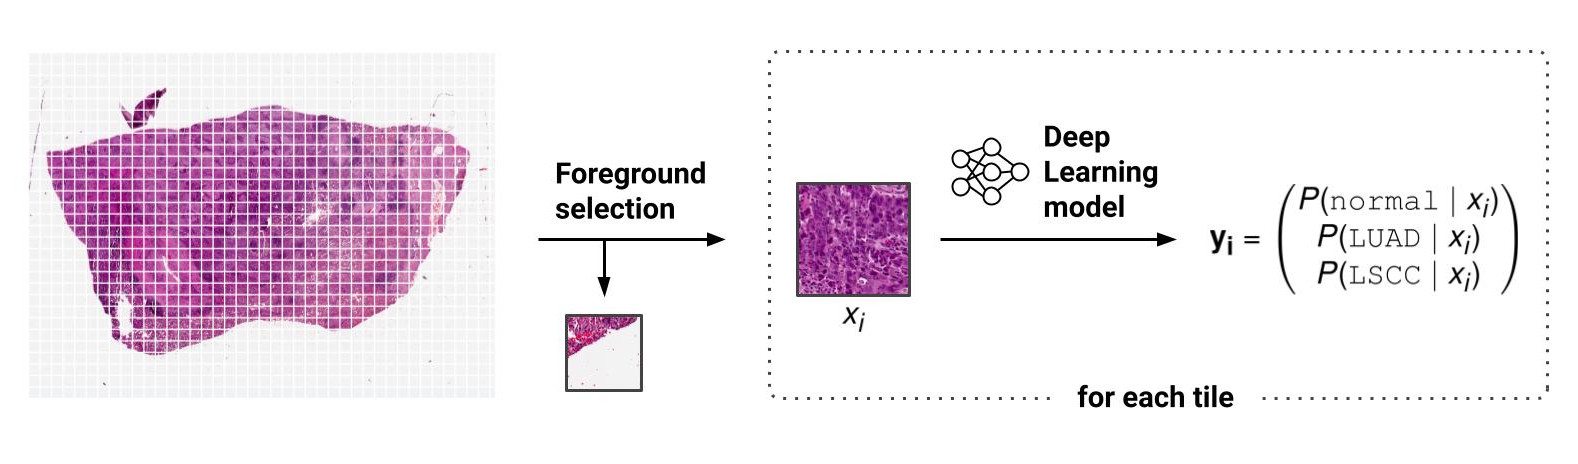

In [26]:
!curl --progress-bar -LJO \
   -H "Accept: application/octet-stream" \
   $MODEL_URL

!unzip -n $MODEL_FILE_PATH

######################################################################## 100.0%
Archive:  ./tcga_pretrained_model256.zip
   creating: tcga_pretrained_model256/
  inflating: tcga_pretrained_model256/saved_model.pb  
  inflating: tcga_pretrained_model256/keras_metadata.pb  
   creating: tcga_pretrained_model256/variables/
  inflating: tcga_pretrained_model256/variables/variables.data-00000-of-00001  
  inflating: tcga_pretrained_model256/variables/variables.index  
   creating: tcga_pretrained_model256/assets/


In [27]:
# Load model
tcga_model_dir = os.path.splitext(MODEL_FILE_PATH)[0]
loaded = tf.saved_model.load(tcga_model_dir)
model = loaded.signatures['serving_default']

In [28]:
def is_foreground(tile: Image.Image) -> bool:
    """
    Function to determine if a tile shows mainly tissue (foreground) or background.
    Returns True if tile shows <= 50% background and False otherwise.
    """
    grey = tile.convert(mode='L')
    thresholded = grey.point(lambda x: 0 if x < 220 else 1, mode='F')
    avg_bkg = np.average(np.array(thresholded))
    return avg_bkg <= 0.5

def predict(model, slides_metadata: pd.DataFrame, coverage: float) -> Predictions:
    """
    Function to perform inference for a certain set of slides using a given pretrained model.
    Returns per-tile predictions as obtained from the model inference plus necessary metadata, e.g.,
    the tile's position in the WSI.
    """
    image_ids = []
    tile_positions = []
    reference_class_indices = []
    predicted_class_probabilities = []

    for index, slide_metadata in tqdm(slides_metadata.iterrows(), total=slides_metadata.shape[0]):
        wsi = WSI(slide_metadata)
        image_id = slide_metadata['digital_slide_id']
        reference_class_index = CLASS_LABEL_TO_INDEX_MAP[slide_metadata['reference_class_label']]
        batch_iterator = BatchIterator(wsi, TILE_SIZE, PIXEL_SPACING, is_foreground,
                                    batch_size=32, coverage=coverage)

        for (batch_images, batch_tile_positions) in batch_iterator:
            batch_predicted_class_probabilities = model(input_1=tf.convert_to_tensor(batch_images, dtype=np.float32))['predictions']
            image_ids.extend([image_id] * len(batch_tile_positions))
            tile_positions.extend(batch_tile_positions)
            reference_class_indices.extend([reference_class_index] * len(batch_tile_positions))
            predicted_class_probabilities.extend(batch_predicted_class_probabilities.numpy().tolist())

    dictionary = {'image_id': image_ids, 'tile_position': tile_positions,
            'reference_class_index': reference_class_indices,
            'predicted_class_index': [p.index(max(p)) for p in predicted_class_probabilities],
            'predicted_class_probabilities': predicted_class_probabilities}
    return Predictions(pd.DataFrame(dictionary))

In [ ]:
# Perform prediction
predictions = predict(model, slides_metadata, coverage=0.1)

# Evaluation

The performance of this model is in the following evaluated quantitatively by means of ROC curves and observed qualitatively using heatmap visualization.

**A ROC analysis** (one-vs-rest) for each of the three classes (normal, LUAD, LSCC) is performed on **tile-level** (tile-based ROC) and on **slide-level** (slide-based ROC). For the slide-level analysis the probabilities for each slide are aggregated by averaging the probabilities of the corresponding tiles. Respective Area under the ROC curve (AUC) values are reported in the table below. ROC curves are also visualized below.

In [ ]:
tile_roc_analysis = perform_tile_based_roc_analysis(predictions)
slide_roc_analysis = perform_slide_based_roc_analysis(predictions)
display(summarize_roc_values(tile_roc_analysis, slide_roc_analysis))

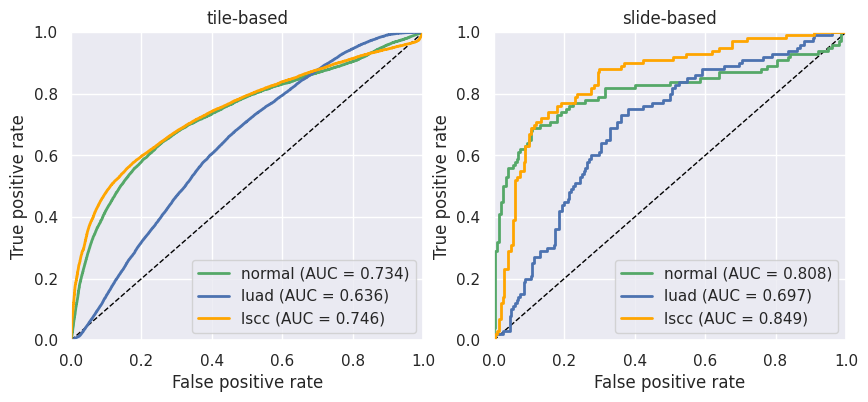

In [31]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
tile_roc_analysis.plot(axes[0])
slide_roc_analysis.plot(axes[1])
plt.show()
plt.close()

**Heatmaps** are generated for visually inspecting the network's predictions for three exemplary slides. The color of each tile in the heatmap corresponds to the class assigned by our model. The hue indicates how confident the network is in this classification. Hereby, a darker hue corresponds to higher confidence. The respective orginal WSI is shown as thumbnail image next to the heatmap.

In [ ]:
hm_slides_metadata = select_slides_for_heatmap(predictions, slides_metadata)
# Re-predict selected slides with 100% coverage of tiles for heatmap visualization
hm_predictions = predict(model, hm_slides_metadata, coverage=1.0)

plot_colormap_legend()
fig, axes = plt.subplots(len(hm_slides_metadata.index), 2, figsize=(10, 9))
for i, (image_id, slide_metadata) in enumerate(hm_slides_metadata.iterrows()):
    wsi = WSI(slide_metadata)
    thumbnail = wsi.get_thumbnail()
    true_tissue_type = slide_metadata['reference_class_label']
    heatmap = generate_heatmap(hm_predictions, image_id)
    axes[i,0].imshow(heatmap)
    axes[i,1].imshow(thumbnail)
    axes[i,1].set_title(true_tissue_type)
    axes[i,0].axis('off')
    axes[i,1].axis('off')

In [ ]:
elapsed_time = time.time() - start_time
print('Notebook execution time: {}'.format(timedelta(seconds=elapsed_time)))

---
*The results shown here are in whole or part based upon data generated by the The Cancer Genome Atlas (TCGA) Research Network and the National Cancer Institute Clinical Proteomic Tumor Analysis Consortium (CPTAC).*

*Copyright 2023 Fraunhofer MEVIS and Harvard Medical School. Redistribution and use of this notebook, with or without modification, are permitted under the terms of the [3-Clause BSD License](https://opensource.org/licenses/BSD-3-Clause).*